Настройка окружения

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))  # Добавляем корень проекта

import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
from tqdm import tqdm

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Импорты из проекта
from src.dataset import MinecraftMobsDataset, get_dataloader
from src.utils import set_seed

set_seed(42)

print("Окружение настроено")

Загрузка конфигурации

In [ ]:
with open('../configs/default.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print("Конфигурация загружена")
print(f"Количество классов: {config['data']['num_classes']}")
print(f"Классы: {config['data']['class_names']}")
print(f"Размер изображений: {config['data']['image_size']}")
print(f"Batch size: {config['data']['batch_size']}")

Загрузка датасета

In [ ]:
train_dataset = MinecraftMobsDataset(
    data_dir=config['data']['raw_path'],
    split='train',
    img_size=config['data']['image_size'],
    class_names=config['data']['class_names']
)

val_dataset = MinecraftMobsDataset(
    data_dir=config['data']['raw_path'],
    split='val',
    img_size=config['data']['image_size'],
    class_names=config['data']['class_names']
)

print(f"Тренировочных изображений: {len(train_dataset)}")
print(f"Валидационных изображений: {len(val_dataset)}")

Статистика датасета

In [ ]:
def analyze_dataset(dataset, name):
    """Анализ датасета"""
    stats = {
        'total_images': len(dataset),
        'total_objects': 0,
        'objects_per_class': Counter(),
        'objects_per_image': [],
        'images_without_objects': 0
    }
    
    print(f"Анализ {name} датасета...")
    for idx in tqdm(range(len(dataset)), desc=f"Processing {name}"):
        sample = dataset[idx]
        boxes = sample['boxes']
        labels = sample['labels']
        
        num_objects = len(boxes)
        stats['total_objects'] += num_objects
        stats['objects_per_image'].append(num_objects)
        
        if num_objects == 0:
            stats['images_without_objects'] += 1
        
        for label in labels:
            class_name = config['data']['class_names'][int(label)]
            stats['objects_per_class'][class_name] += 1
    
    return stats

# Собираем статистику
train_stats = analyze_dataset(train_dataset, "тренировочного")
val_stats = analyze_dataset(val_dataset, "валидационного")

print("\n" + "="*60)
print("СТАТИСТИКА ДАТАСЕТА")
print("="*60)
print(f"\nТренировочный:")
print(f"  Изображений: {train_stats['total_images']}")
print(f"  Всего объектов: {train_stats['total_objects']}")
print(f"  Среднее объектов/изобр: {train_stats['total_objects']/train_stats['total_images']:.1f}")
print(f"  Без объектов: {train_stats['images_without_objects']}")

print(f"\nВалидационный:")
print(f"  Изображений: {val_stats['total_images']}")
print(f"  Всего объектов: {val_stats['total_objects']}")
print(f"  Среднее объектов/изобр: {val_stats['total_objects']/val_stats['total_images']:.1f}")
print(f"  Без объектов: {val_stats['images_without_objects']}")

Визуализация распределения классов

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Тренировочный
classes = list(train_stats['objects_per_class'].keys())
counts_train = list(train_stats['objects_per_class'].values())
axes[0].bar(classes, counts_train, color=sns.color_palette("husl", len(classes)))
axes[0].set_title('Распределение классов (Train)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество объектов')
axes[0].tick_params(axis='x', rotation=45)

# Валидационный
counts_val = [val_stats['objects_per_class'].get(c, 0) for c in classes]
axes[1].bar(classes, counts_val, color=sns.color_palette("husl", len(classes)))
axes[1].set_title('Распределение классов (Val)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество объектов')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Проверка баланса
print("\nБаланс классов:")
for cls in classes:
    train_pct = train_stats['objects_per_class'][cls] / train_stats['total_objects'] * 100
    val_pct = val_stats['objects_per_class'].get(cls, 0) / max(1, val_stats['total_objects']) * 100
    print(f"  {cls:12s}: Train={train_pct:5.1f}% | Val={val_pct:5.1f}%")

Распределение объектов на изображении

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма количества объектов
max_objects = max(max(train_stats['objects_per_image']), max(val_stats['objects_per_image']))
bins = np.arange(0, max_objects + 2) - 0.5

axes[0].hist(train_stats['objects_per_image'], bins=bins, alpha=0.7, label='Train', 
             color='blue', edgecolor='black')
axes[0].hist(val_stats['objects_per_image'], bins=bins, alpha=0.7, label='Val',
             color='orange', edgecolor='black')
axes[0].set_xlabel('Количество объектов')
axes[0].set_ylabel('Количество изображений')
axes[0].set_title('Распределение количества объектов на изображении', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
data_to_plot = [train_stats['objects_per_image'], val_stats['objects_per_image']]
bp = axes[1].boxplot(data_to_plot, labels=['Train', 'Val'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Количество объектов')
axes[1].set_title('Box plot количества объектов', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/objects_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Визуализация примеров из датасета

In [ ]:
def denormalize_image(tensor):
    """Денормализация изображения"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Показываем примеры
num_examples = 8
indices = np.random.choice(len(train_dataset), num_examples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flat

for i, idx in enumerate(indices):
    sample = train_dataset[idx]
    image = denormalize_image(sample['image'])
    boxes = sample['boxes']
    labels = sample['labels']
    
    axes[i].imshow(image)
    
    # Рисуем боксы
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box
        class_name = config['data']['class_names'][int(label)]
        
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                            fill=False, color='red', linewidth=2)
        axes[i].add_patch(rect)
        axes[i].text(x1, y1-10, class_name, 
                    color='white', fontsize=8,
                    bbox=dict(facecolor='red', alpha=0.7))
    
    axes[i].set_title(f"Image {idx} - {len(boxes)} objects")
    axes[i].axis('off')

plt.suptitle('Примеры из тренировочного датасета', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()

Анализ размера bounding boxes

In [ ]:
all_box_sizes = []
all_box_ratios = []

for idx in tqdm(range(len(train_dataset)), desc="Анализ размеров боксов"):
    sample = train_dataset[idx]
    boxes = sample['boxes']
    
    for box in boxes:
        x1, y1, x2, y2 = box
        w = x2 - x1
        h = y2 - y1
        area = w * h
        
        # Относительный размер
        img_size = config['data']['image_size']
        rel_area = area / (img_size * img_size)
        all_box_sizes.append(rel_area)
        
        # Соотношение сторон
        if h > 0:
            ratio = w / h
            all_box_ratios.append(ratio)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Размеры
axes[0].hist(all_box_sizes, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Относительная площадь')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение размеров bounding boxes', fontweight='bold')
axes[0].axvline(np.mean(all_box_sizes), color='red', linestyle='--', 
                label=f'Среднее: {np.mean(all_box_sizes):.3f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Соотношения сторон
axes[1].hist(all_box_ratios, bins=50, color='green', alpha=0.7, edgecolor='black', 
            range=(0, 5))
axes[1].set_xlabel('Соотношение сторон (w/h)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение соотношений сторон', fontweight='bold')
axes[1].axvline(np.mean(all_box_ratios), color='red', linestyle='--',
                label=f'Среднее: {np.mean(all_box_ratios):.2f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Box plot размеров по классам (если есть разметка)
sizes_by_class = {name: [] for name in config['data']['class_names']}
for idx in range(min(500, len(train_dataset))):  # Ограничим для скорости
    sample = train_dataset[idx]
    for box, label in zip(sample['boxes'], sample['labels']):
        x1, y1, x2, y2 = box
        area = ((x2-x1) * (y2-y1)) / (config['data']['image_size']**2)
        class_name = config['data']['class_names'][int(label)]
        sizes_by_class[class_name].append(area)

data_for_boxplot = [sizes for sizes in sizes_by_class.values() if sizes]
labels_for_boxplot = [name for name, sizes in sizes_by_class.items() if sizes]
axes[2].boxplot(data_for_boxplot, labels=labels_for_boxplot)
axes[2].set_ylabel('Относительная площадь')
axes[2].set_title('Размеры боксов по классам', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/box_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nСтатистика размеров боксов:")
print(f"  Средняя площадь: {np.mean(all_box_sizes):.3f} (от всего изображения)")
print(f"  Медианная площадь: {np.median(all_box_sizes):.3f}")
print(f"  Min: {np.min(all_box_sizes):.4f}, Max: {np.max(all_box_sizes):.4f}")
print(f"  Среднее соотношение сторон: {np.mean(all_box_ratios):.2f}")

Проверка загрузчика данных

In [ ]:
train_loader = get_dataloader(config['data'], 'train')
val_loader = get_dataloader(config['data'], 'val')

# Получаем первый батч
batch = next(iter(train_loader))

print("Информация о батче:")
print(f"  Размер батча: {batch['image'].shape}")
print(f"  Тип изображений: {batch['image'].dtype}")
print(f"  Диапазон значений: [{batch['image'].min():.2f}, {batch['image'].max():.2f}]")
print(f"  Ключи: {list(batch.keys())}")

# Проверяем разные изображения в батче
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat[:8]):
    if i < len(batch['image']):
        img = denormalize_image(batch['image'][i])
        ax.imshow(img)
        ax.set_title(f"Objects: {len(batch['boxes'][i])}")
    ax.axis('off')
plt.suptitle('Батч из даталоадера', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
python

Выводы и рекомендации

In [ ]:
print("="*60)
print("ВЫВОДЫ ПОСЛЕ АНАЛИЗА ДАННЫХ")
print("="*60)

# Проверка баланса классов
class_counts = train_stats['objects_per_class']
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"\n1. Баланс классов:")
if imbalance_ratio < 2:
    print(f"   + Хороший баланс (соотношение {imbalance_ratio:.1f}:1)")
elif imbalance_ratio < 5:
    print(f"   !  Умеренный дисбаланс (соотношение {imbalance_ratio:.1f}:1)")
    print(f"   Рекомендация: Использовать WeightedRandomSampler или class weights")
else:
    print(f"   - Сильный дисбаланс (соотношение {imbalance_ratio:.1f}:1)")
    print(f"   Рекомендация: Обязательно использовать балансировку классов")

# Размер датасета
print(f"\n2. Размер датасета:")
print(f"   Тренировочных изображений: {len(train_dataset)}")
print(f"   Валидационных: {len(val_dataset)}")

if len(train_dataset) < 500:
    print(f"   !  Маленький датасет. Рекомендуется:")
    print(f"      - Использовать сильные аугментации (Mosaic, MixUp)")
    print(f"      - Transfer learning (предобученные веса)")
    print(f"      - Рассмотреть сбор дополнительных данных")
else:
    print(f"   + Достаточный размер датасета")

# Объекты на изображении
avg_objects = train_stats['total_objects'] / train_stats['total_images']
print(f"\n3. Плотность объектов:")
print(f"   Среднее объектов на изображении: {avg_objects:.1f}")

if train_stats['images_without_objects'] > len(train_dataset) * 0.1:
    print(f"   !  Много изображений без объектов ({train_stats['images_without_objects']})")
    print(f"      Рекомендация: Добавить негативные примеры или фильтровать датасет")

# Размер боксов
small_boxes = sum(1 for s in all_box_sizes if s < 0.01)
small_pct = small_boxes / len(all_box_sizes) * 100
print(f"\n4. Маленькие объекты:")
print(f"   Объектов меньше 1% площади: {small_pct:.1f}%")
if small_pct > 20:
    print(f"   !  Много маленьких объектов. Рекомендация:")
    print(f"      - Использовать больший размер изображений")
    print(f"      - Включить Mosaic augmentation")

print(f"\n5. Общие рекомендации:")
print(f"   - Модели для тестирования: YOLO (быстро), Faster R-CNN (точно), DETR (современно)")
print(f"   - Метрики: mAP@0.5, mAP@0.5:0.95, Precision, Recall")
print(f"   - Аугментации: Mosaic + MixUp для YOLO, Albumentations для остальных")
print(f"   - Обучение: не менее 100 эпох с EarlyStopping")
print("="*60)

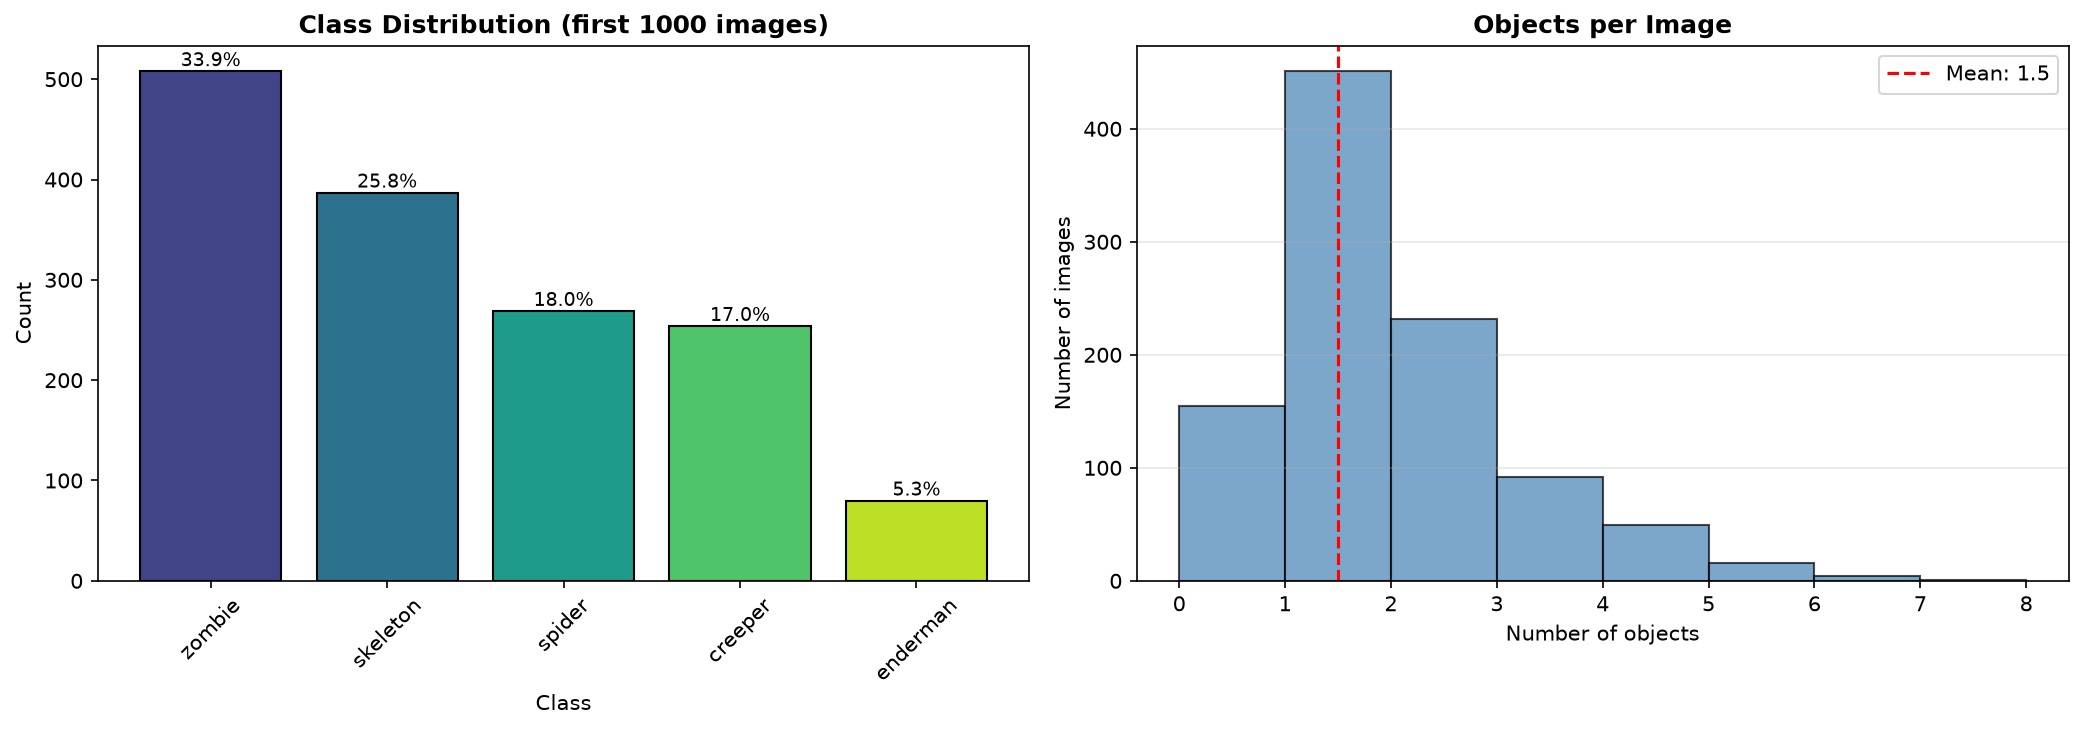

Сохранение статистики

In [ ]:
import json

stats_to_save = {
    'train': {
        'num_images': len(train_dataset),
        'num_objects': train_stats['total_objects'],
        'avg_objects_per_image': train_stats['total_objects'] / len(train_dataset),
        'class_distribution': dict(train_stats['objects_per_class']),
        'images_without_objects': train_stats['images_without_objects']
    },
    'val': {
        'num_images': len(val_dataset),
        'num_objects': val_stats['total_objects'],
        'avg_objects_per_image': val_stats['total_objects'] / len(val_dataset),
        'class_distribution': dict(val_stats['objects_per_class']),
        'images_without_objects': val_stats['images_without_objects']
    },
    'box_statistics': {
        'avg_relative_size': float(np.mean(all_box_sizes)),
        'median_relative_size': float(np.median(all_box_sizes)),
        'avg_aspect_ratio': float(np.mean(all_box_ratios)),
        'small_boxes_percentage': small_pct
    }
}

os.makedirs('../results', exist_ok=True)
with open('../results/dataset_statistics.json', 'w', encoding='utf-8') as f:
    json.dump(stats_to_save, f, indent=2, ensure_ascii=False)

print("+ Статистика сохранена в results/dataset_statistics.json")
print("+ Графики сохранены в results/plots/")
print("\n Созданные файлы:")
print("  - results/plots/class_distribution.png")
print("  - results/plots/objects_distribution.png")
print("  - results/plots/dataset_examples.png")
print("  - results/plots/box_analysis.png")
print("  - results/dataset_statistics.json")